# Домашняя работа 2
 Изучение GCN, GraphSAGE, GAT, GIN — на задачах "node classification" и "link prediction"




В этой домашней работе вам предстоит:

- освоить и углубить понимание нескольких графовых нейросетевых архитектур (GCN, GraphSAGE, GAT, GIN)
-  применить их к задачам классификации узлов и предсказания рёбер
- исследовать влияние глубины, скрытой размерности, оптимизации GNN на качество обучения
- построить сравнительные эксперименты и сделать собственные выводы о преимуществах разных подходов

In [2]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.1 MB/s eta 0:00:00


In [3]:
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import RandomLinkSplit
import networkx as nx

from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Загрузка и визуализация данных

Датасет: Cora - Граф научных цитирований

In [4]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]
print(data)

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


# Часть 1. Node Classification

### 1.1 Реализация расширенного GCN

Создайте GCN-модель с:

- тремя слоями GCNConv,
- Dropout после второго слоя,
- активацией ReLU в скрытых слоях.

**Вопросы:**

- Улучшилось ли качество на Cora в сравнении с результатом, который был получен на практике?
- Как изменилась динамика сходимости?
- Наблюдается ли переобучение?

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN3(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout_p=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, out_dim)
        self.dropout_p = dropout_p

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Dropout после второго слоя
        x = F.dropout(x, p=self.dropout_p, training=self.training)

        x = self.conv3(x, edge_index)

        return F.log_softmax(x, dim=1)


In [6]:
import copy

def train_node_classification(model, data, optimizer, epochs=200, patience=300):
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # validation
        val_acc = evaluate_node_classification(model, data, data.val_mask)
        val_accuracies.append(val_acc)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}, Val Acc: {val_acc:.4f}")

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)


    # load best
    if best_model_state:
        model.load_state_dict(best_model_state)

    # final metrics
    train_acc = evaluate_node_classification(model, data, data.train_mask)
    val_acc = evaluate_node_classification(model, data, data.val_mask)
    test_acc = evaluate_node_classification(model, data, data.test_mask)

    return train_acc, val_acc, test_acc


def evaluate_node_classification(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        acc = (pred == data.y[mask]).sum().item() / mask.sum().item()
        return acc


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

model = GCN3(
    in_dim = dataset.num_features,
    hidden_dim = 64,           # можно менять
    out_dim = dataset.num_classes,
    dropout_p = 0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

train_acc, val_acc, test_acc = train_node_classification(model, data, optimizer, epochs=300)

# test accuracy
test_acc = evaluate_node_classification(model, data, data.test_mask)
print(f"Точность на тесте: {test_acc:.4f}")


Epoch 000, Loss: 1.9478, Val Acc: 0.4760
Epoch 010, Loss: 0.6433, Val Acc: 0.7980
Epoch 020, Loss: 0.0583, Val Acc: 0.7820
Epoch 030, Loss: 0.0191, Val Acc: 0.7840
Epoch 040, Loss: 0.0098, Val Acc: 0.7800
Epoch 050, Loss: 0.0039, Val Acc: 0.7620
Epoch 060, Loss: 0.0046, Val Acc: 0.7760
Epoch 070, Loss: 0.0056, Val Acc: 0.7800
Epoch 080, Loss: 0.0057, Val Acc: 0.7700
Epoch 090, Loss: 0.0089, Val Acc: 0.7680
Epoch 100, Loss: 0.0053, Val Acc: 0.7800
Epoch 110, Loss: 0.0082, Val Acc: 0.7700
Epoch 120, Loss: 0.0063, Val Acc: 0.7720
Epoch 130, Loss: 0.0102, Val Acc: 0.7680
Epoch 140, Loss: 0.0070, Val Acc: 0.7720
Epoch 150, Loss: 0.0058, Val Acc: 0.7620
Epoch 160, Loss: 0.0070, Val Acc: 0.7620
Epoch 170, Loss: 0.0113, Val Acc: 0.7660
Epoch 180, Loss: 0.0057, Val Acc: 0.7680
Epoch 190, Loss: 0.0051, Val Acc: 0.7740
Epoch 200, Loss: 0.0077, Val Acc: 0.7820
Epoch 210, Loss: 0.0055, Val Acc: 0.7700
Epoch 220, Loss: 0.0060, Val Acc: 0.7700
Epoch 230, Loss: 0.0075, Val Acc: 0.7800
Epoch 240, Loss:

1. Улучшилось ли качество на Cora в сравнении с результатом, который был получен на практике?

- да, качество чутка улучшилось  - на практике было 0.789, а здесь 0.7940

2. Как изменилась динамика сходимости?

- значение Accuracy более стабильное, чем на практике

3. Наблюдается ли переобучение?

- Да, переобучение наблюдается, тк после 150 эпохи лосс меньше 0.005

### 1.2 Исследование глубины признакового пространства

Проведите эксперимент с различными значениями скрытой размерности:

```
hidden_dim = 8, 16, 32, 64
```

Постройте таблицу:

| Hidden Dim | Train Acc | Val Acc | Test Acc |
| ---------- | --------- | ------- | -------- |

**Вопросы:**

- Сравните полученные результаты
- Влияет ли размерность на качество обучения?


In [9]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv
import copy
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def run_experiment(hidden_dims=[8,16,32,64], seeds=[42, 0, 7], epochs=300, lr=0.005, dropout=0.5, weight_decay=5e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # load dataset
    dataset = Planetoid(root='/tmp/Cora', name='Cora')
    data = dataset[0].to(device)

    results = []  # will hold dicts with results

    for h in hidden_dims:
        run_train_acc = []
        run_val_acc = []
        run_test_acc = []

        for seed in seeds:
            # deterministic-ish setup
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(seed)

            model = GCN3(in_dim=dataset.num_node_features, hidden_dim=h, out_dim=dataset.num_classes, dropout_p=dropout).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

            # train
            train_acc, val_acc, test_acc = train_node_classification(model, data, optimizer, epochs=epochs, patience=300)

            run_train_acc.append(train_acc)
            run_val_acc.append(val_acc)
            run_test_acc.append(test_acc)

            print(f"hidden_dim={h}, seed={seed} -> train {train_acc:.4f}, val {val_acc:.4f}, test {test_acc:.4f}")

        results.append({
            'hidden_dim': h,
            'train_acc_mean': np.mean(run_train_acc),
            'train_acc_std': np.std(run_train_acc),
            'val_acc_mean': np.mean(run_val_acc),
            'val_acc_std': np.std(run_val_acc),
            'test_acc_mean': np.mean(run_test_acc),
            'test_acc_std': np.std(run_test_acc),
        })

    df = pd.DataFrame(results)
    return df

Epoch 000, Loss: 1.9469, Val Acc: 0.3080
Epoch 010, Loss: 1.6489, Val Acc: 0.3420
Epoch 020, Loss: 1.3334, Val Acc: 0.5240
Epoch 030, Loss: 1.0002, Val Acc: 0.6940
Epoch 040, Loss: 0.7063, Val Acc: 0.7400
Epoch 050, Loss: 0.5009, Val Acc: 0.7620
Epoch 060, Loss: 0.4132, Val Acc: 0.7740
Epoch 070, Loss: 0.3273, Val Acc: 0.7760
Epoch 080, Loss: 0.3203, Val Acc: 0.7760
Epoch 090, Loss: 0.1877, Val Acc: 0.7640
Epoch 100, Loss: 0.2051, Val Acc: 0.7760
Epoch 110, Loss: 0.2538, Val Acc: 0.7540
Epoch 120, Loss: 0.2018, Val Acc: 0.7640
Epoch 130, Loss: 0.1730, Val Acc: 0.7520
Epoch 140, Loss: 0.1132, Val Acc: 0.7680
Epoch 150, Loss: 0.1666, Val Acc: 0.7620
Epoch 160, Loss: 0.1965, Val Acc: 0.7660
Epoch 170, Loss: 0.1544, Val Acc: 0.7560
Epoch 180, Loss: 0.1652, Val Acc: 0.7560
Epoch 190, Loss: 0.1997, Val Acc: 0.7540
Epoch 200, Loss: 0.1609, Val Acc: 0.7600
Epoch 210, Loss: 0.1549, Val Acc: 0.7500
Epoch 220, Loss: 0.1076, Val Acc: 0.7580
Epoch 230, Loss: 0.1528, Val Acc: 0.7500
Epoch 240, Loss:

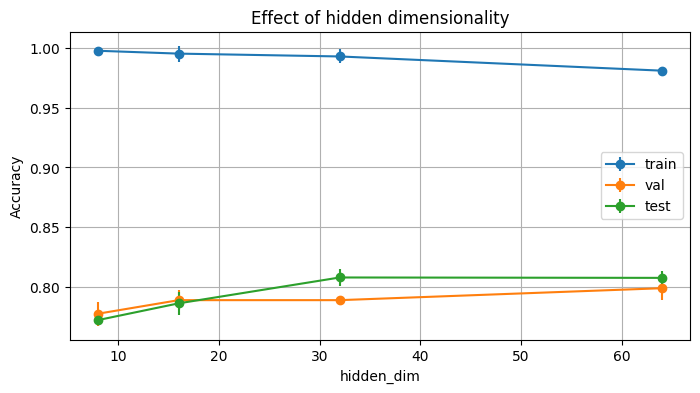

In [11]:
hidden_dims = [8, 16, 32, 64]
seeds = [42, 0, 7]   # можно увеличить до 5 сидов для надёжности
df_results = run_experiment(hidden_dims=hidden_dims, seeds=seeds, epochs=300, lr=0.005, dropout=0.5, weight_decay=5e-4)
print(df_results.to_string(index=False))

    # Визуализация
plt.figure(figsize=(8,4))
plt.errorbar(df_results['hidden_dim'], df_results['train_acc_mean'], yerr=df_results['train_acc_std'], label='train', marker='o')
plt.errorbar(df_results['hidden_dim'], df_results['val_acc_mean'], yerr=df_results['val_acc_std'], label='val', marker='o')
plt.errorbar(df_results['hidden_dim'], df_results['test_acc_mean'], yerr=df_results['test_acc_std'], label='test', marker='o')
plt.xlabel('hidden_dim')
plt.ylabel('Accuracy')
plt.title('Effect of hidden dimensionality')
plt.legend()
plt.grid(True)
plt.show()


1) Сравните полученные результаты

- наиболее стабильные результаты получились при 64 hidden_dim -  акураси на валидации и тесте очень близки, при этом стандартное отклонение минимальное

- при этом на трейне акураси падает при росте hodden_dim, а на тесте и валидации обратная тенденция - акураси растет при росте hidden_dim

2) Влияет ли размерность на качество обучения?
Да, на графике видно, что при росте размерности также улучшается качество на валидации и тесте

### 1.3 Исследование нормализаций

Добавьте BatchNorm / LayerNorm / PairNorm (можно комбинировать) между слоями GCN и сравните:

- скорость сходимости,
- валидационную точность,
- чувствительность к learning rate.

**Вопросы:**
- Оцените каждый вариант:
    - Улучшилась ли стабильность обучения?
    - Снизился ли эффект over-smoothing?
- Какой вариант нормализации показал себя лучше всего для данной задачи?



In [12]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import copy
import matplotlib.pyplot as plt
from collections import defaultdict


class PairNorm(nn.Module):
    """
    Простая реализация PairNorm (вариант 'PN'):
    x <- x - mean(x, dim=0)
    x <- x / (sqrt(mean(sum(x^2, dim=1))) + eps)
    """
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        # x: [N, F]
        mean = x.mean(dim=0, keepdim=True)
        x = x - mean
        sq = (x ** 2).sum(dim=1)
        mean_norm = torch.sqrt(sq.mean() + self.eps)
        x = x / (mean_norm + self.eps)
        return x


class GCN3_Norm(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, norm_type=None, dropout_p=0.5):
        """
        norm_type: None | 'batch' | 'layer' | 'pair' | 'batch_pair' | 'layer_pair'
        Нормализция применяется после conv и до ReLU для первых двух слоёв.
        """
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, out_dim)
        self.dropout_p = dropout_p
        self.norm_type = norm_type

        if norm_type in ('batch', 'batch_pair'):
            self.bn1 = nn.BatchNorm1d(hidden_dim)
            self.bn2 = nn.BatchNorm1d(hidden_dim)
        else:
            self.bn1 = None
            self.bn2 = None

        if norm_type in ('layer', 'layer_pair'):
            self.ln1 = nn.LayerNorm(hidden_dim)
            self.ln2 = nn.LayerNorm(hidden_dim)
        else:
            self.ln1 = None
            self.ln2 = None

        if norm_type in ('pair', 'batch_pair', 'layer_pair'):
            self.pn = PairNorm()
        else:
            self.pn = None

    def apply_norm(self, x, layer_idx):
        # layer_idx: 1 or 2
        if self.bn1 is not None and layer_idx == 1:
            # BatchNorm expects shape [N, features] — ok
            x = self.bn1(x)
        if self.bn2 is not None and layer_idx == 2:
            x = self.bn2(x)
        if self.ln1 is not None and layer_idx == 1:
            x = self.ln1(x)
        if self.ln2 is not None and layer_idx == 2:
            x = self.ln2(x)
        if self.pn is not None:
            # PairNorm applied after other norms if present (as a variant)
            x = self.pn(x)
        return x

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        # norm after conv1
        x = self.apply_norm(x, layer_idx=1)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.apply_norm(x, layer_idx=2)
        x = F.relu(x)

        x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)


def evaluate_node_classification(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        acc = (pred == data.y[mask]).sum().item() / mask.sum().item()
        return acc

def train_node_classification_return_history(model, data, optimizer, epochs=300, patience=50):
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0

    val_hist = []
    train_hist = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # metrics
        train_acc = evaluate_node_classification(model, data, data.train_mask)
        val_acc = evaluate_node_classification(model, data, data.val_mask)

        train_hist.append(train_acc)
        val_hist.append(val_acc)

        if val_acc > best_val_acc + 1e-12:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    train_acc_final = evaluate_node_classification(model, data, data.train_mask)
    val_acc_final = evaluate_node_classification(model, data, data.val_mask)
    test_acc_final = evaluate_node_classification(model, data, data.test_mask)

    # return history and best metrics + epoch of best val
    return {
        'train_hist': train_hist,
        'val_hist': val_hist,
        'train_acc': train_acc_final,
        'val_acc': val_acc_final,
        'test_acc': test_acc_final,
        'best_epoch': best_epoch if best_model_state is not None else len(val_hist)-1
    }


def run_norm_experiments(norm_types=None, lrs=None, seeds=None,
                         hidden_dim=32, epochs=300, patience=50, dropout=0.5, weight_decay=5e-4):
    if norm_types is None:
        norm_types = [None, 'batch', 'layer', 'pair', 'batch_pair', 'layer_pair']
    if lrs is None:
        lrs = [0.01, 0.005, 0.001]
    if seeds is None:
        seeds = [42, 0, 7]

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=NormalizeFeatures())
    data = dataset[0].to(device)

    records = []

    # For plotting aggregated val curves per norm_type at best lr later
    val_curves = defaultdict(list)

    for norm in norm_types:
        for lr in lrs:
            # multiple seeds to reduce случайность
            seed_results = []
            seed_best_epochs = []
            seed_val_hists = []
            for seed in seeds:
                torch.manual_seed(seed)
                np.random.seed(seed)
                random.seed(seed)
                if torch.cuda.is_available():
                    torch.cuda.manual_seed(seed)

                model = GCN3_Norm(in_dim=dataset.num_node_features,
                                  hidden_dim=hidden_dim,
                                  out_dim=dataset.num_classes,
                                  norm_type=norm,
                                  dropout_p=dropout).to(device)

                optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

                res = train_node_classification_return_history(model, data, optimizer,
                                                               epochs=epochs, patience=patience)

                seed_results.append((res['train_acc'], res['val_acc'], res['test_acc']))
                seed_best_epochs.append(res['best_epoch'])
                seed_val_hists.append(res['val_hist'])
                print(f"norm={norm}, lr={lr}, seed={seed} -> train {res['train_acc']:.4f}, val {res['val_acc']:.4f}, test {res['test_acc']:.4f}, best_epoch={res['best_epoch']}")

            # aggregate seeds
            train_mean = np.mean([r[0] for r in seed_results])
            train_std = np.std([r[0] for r in seed_results])
            val_mean = np.mean([r[1] for r in seed_results])
            val_std = np.std([r[1] for r in seed_results])
            test_mean = np.mean([r[2] for r in seed_results])
            test_std = np.std([r[2] for r in seed_results])
            best_epoch_mean = np.mean(seed_best_epochs)

            records.append({
                'norm': str(norm),
                'lr': lr,
                'hidden_dim': hidden_dim,
                'train_acc_mean': train_mean,
                'train_acc_std': train_std,
                'val_acc_mean': val_mean,
                'val_acc_std': val_std,
                'test_acc_mean': test_mean,
                'test_acc_std': test_std,
                'best_epoch_mean': best_epoch_mean
            })

            # keep val hist average (pad to same length)
            max_len = max(len(h) for h in seed_val_hists)
            padded = []
            for h in seed_val_hists:
                arr = np.array(h)
                if len(arr) < max_len:
                    arr = np.pad(arr, (0, max_len - len(arr)), constant_values=np.nan)
                padded.append(arr)
            mean_val_curve = np.nanmean(np.vstack(padded), axis=0)
            val_curves[(norm, lr)] = mean_val_curve

    df = pd.DataFrame.from_records(records)
    return df, val_curves


norm=None, lr=0.01, seed=42 -> train 0.9929, val 0.8060, test 0.8070, best_epoch=77
norm=None, lr=0.01, seed=0 -> train 1.0000, val 0.7880, test 0.7890, best_epoch=117
norm=None, lr=0.01, seed=7 -> train 1.0000, val 0.7980, test 0.7960, best_epoch=108
norm=None, lr=0.005, seed=42 -> train 0.9929, val 0.7880, test 0.8110, best_epoch=107
norm=None, lr=0.005, seed=0 -> train 1.0000, val 0.8000, test 0.7980, best_epoch=128
norm=None, lr=0.005, seed=7 -> train 1.0000, val 0.7940, test 0.7860, best_epoch=127
norm=None, lr=0.001, seed=42 -> train 0.8929, val 0.7300, test 0.7550, best_epoch=38
norm=None, lr=0.001, seed=0 -> train 0.9500, val 0.7920, test 0.8120, best_epoch=144
norm=None, lr=0.001, seed=7 -> train 0.8929, val 0.6600, test 0.6550, best_epoch=28
norm=batch, lr=0.01, seed=42 -> train 1.0000, val 0.7020, test 0.6980, best_epoch=143
norm=batch, lr=0.01, seed=0 -> train 1.0000, val 0.6800, test 0.6940, best_epoch=99
norm=batch, lr=0.01, seed=7 -> train 1.0000, val 0.7040, test 0.7060

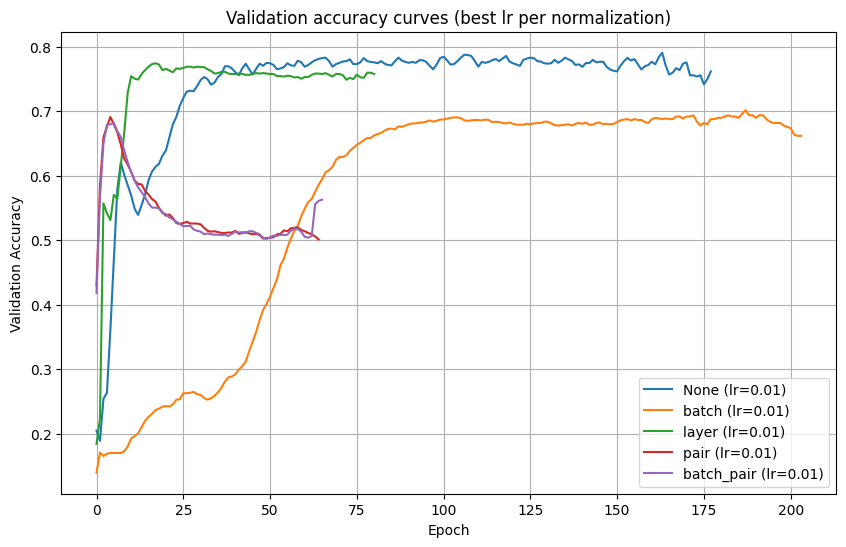

In [13]:
norm_types = [None, 'batch', 'layer', 'pair', 'batch_pair']
lrs = [0.01, 0.005, 0.001]
seeds = [42, 0, 7]
hidden_dim = 32

df_results, val_curves = run_norm_experiments(norm_types=norm_types, lrs=lrs, seeds=seeds,
                                                  hidden_dim=hidden_dim, epochs=300, patience=60,
                                                  dropout=0.5, weight_decay=5e-4)

print(df_results.to_string(index=False))

best_by_norm = df_results.loc[df_results.groupby('norm')['val_acc_mean'].idxmax()]
print("\n=== Лучший lr для каждой нормализации ===")
print(best_by_norm[['norm','lr','val_acc_mean','val_acc_std','test_acc_mean','test_acc_std','best_epoch_mean']].to_string(index=False))

    # Визуализация: для каждого норм типа нарисуем кривую val acc для лучшего lr
plt.figure(figsize=(10,6))
for norm in norm_types:
    row = best_by_norm[best_by_norm['norm']==str(norm)]
    if row.empty:
        continue
    best_lr = float(row['lr'].values[0])
    curve = val_curves[(norm, best_lr)]
    plt.plot(curve, label=f"{norm} (lr={best_lr})")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation accuracy curves (best lr per normalization)")
plt.legend()
plt.grid(True)
plt.show()


1) Оцените каждый вариант:
  - Улучшилась ли стабильность обучения?
    - На графике видно, что без нормализации («None») кривая точности на валидации развивается менее стабильно и достигает более низкого уровня. BatchNorm заметно ускоряет и стабилизирует обучение
    -  LayerNorm дает умеренное улучшени(тк изначально это не графовый метод)
    -  BatchNorm+PairNorm дает лучший результат
  - Снизился ли эффект over-smoothing?
    - эффект over-smoothing заметно снизился - в целом РairNorm обязан явно снижать  oversmoothing, так как сохраняет различимость узлов даже на более глубокой архитектуре

2) Какой вариант нормализации показал себя лучше всего для данной задачи?
  - BatchNorm+PairNorm дает лучший результат  

### 1.4 Residual Connections (Skip Connections)

Добавление остаточных связей:

$
h_v^{(k+1)} = h_v^{(k)} + \text{GCNLayer}(h_v^{(k)})
$

— улучшает распространение градиентов и сохраняет индивидуальность узлов.

Задание:
1. Добавьте residual connection между слоями GCN.
2. Проверьте, можно ли теперь использовать более глубокую модель (3–4 слоя)

**Вопросы:**

* Улучшается ли обучение GCN?
* Перестаёт ли сеть «слишком усреднять» узлы?



In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class ResidualGCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.gcn = GCNConv(in_dim, out_dim)
        self.dropout = dropout

        # Если размерности отличаются, делаем линейное преобразование
        if in_dim != out_dim:
            self.res_proj = nn.Linear(in_dim, out_dim)
        else:
            self.res_proj = None

    def forward(self, x, edge_index):
        residual = x
        out = self.gcn(x, edge_index)
        out = F.relu(out)
        out = F.dropout(out, p=self.dropout, training=self.training)

        if self.res_proj is not None:
            residual = self.res_proj(residual)

        return out + residual


In [15]:
class ResidualGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=3, dropout=0.5):
        super().__init__()

        layers = []
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]

        for i in range(num_layers):
            layers.append(
                ResidualGCNLayer(dims[i], dims[i+1], dropout=dropout)
            )

        self.layers = nn.ModuleList(layers)

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = layer(x, edge_index)

        # последний слой без ReLU и дропа
        x = self.layers[-1].gcn(x, edge_index)
        return x


In [16]:
def train_residual(model, data, epochs=300, lr=0.01, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val = 0
    best_test = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)

        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        preds = out.argmax(dim=1)

        train_acc = (preds[data.train_mask] == data.y[data.train_mask]).float().mean().item()
        val_acc = (preds[data.val_mask] == data.y[data.val_mask]).float().mean().item()
        test_acc = (preds[data.test_mask] == data.y[data.test_mask]).float().mean().item()

        if val_acc > best_val:
            best_val = val_acc
            best_test = test_acc

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val: {val_acc:.4f}")

    return best_val, best_test


In [17]:
from torch_geometric.datasets import Planetoid
dataset = Planetoid(root=".", name="Cora")
data = dataset[0]

for layers in [2, 3, 4]:
    print(f"\n===== {layers} layers =====")
    model = ResidualGCN(
        in_dim=dataset.num_node_features,
        hidden_dim=64,
        out_dim=dataset.num_classes,
        num_layers=layers,
        dropout=0.5,
    )
    val_acc, test_acc = train_residual(model, data)
    print(f"Best Val: {val_acc:.4f} | Best Test: {test_acc:.4f}")


Processing...
Done!



===== 2 layers =====
Epoch 000 | Loss: 1.9362 | Val: 0.1700
Epoch 050 | Loss: 0.0051 | Val: 0.7800
Epoch 100 | Loss: 0.0056 | Val: 0.7720
Epoch 150 | Loss: 0.0047 | Val: 0.7540
Epoch 200 | Loss: 0.0041 | Val: 0.7700
Epoch 250 | Loss: 0.0043 | Val: 0.7660
Best Val: 0.7840 | Best Test: 0.7980

===== 3 layers =====
Epoch 000 | Loss: 1.9408 | Val: 0.1980
Epoch 050 | Loss: 0.0051 | Val: 0.7400
Epoch 100 | Loss: 0.0025 | Val: 0.7720
Epoch 150 | Loss: 0.0022 | Val: 0.7520
Epoch 200 | Loss: 0.0026 | Val: 0.7660
Epoch 250 | Loss: 0.0023 | Val: 0.7700
Best Val: 0.7860 | Best Test: 0.8000

===== 4 layers =====
Epoch 000 | Loss: 1.9581 | Val: 0.1400
Epoch 050 | Loss: 0.0003 | Val: 0.7540
Epoch 100 | Loss: 0.0013 | Val: 0.7500
Epoch 150 | Loss: 0.0014 | Val: 0.7440
Epoch 200 | Loss: 0.0017 | Val: 0.7420
Epoch 250 | Loss: 0.0039 | Val: 0.7400
Best Val: 0.7780 | Best Test: 0.7960


**Вопросы:**

1) Улучшается ли обучение GCN?
- обучение улучшается между 2-3 слоем, при этом на 4 уже падает(как будто он чутка излишний на данном датасете)

2)  Перестаёт ли сеть «слишком усреднять» узлы?
- да, качество растет

### 1.5 DropEdge

DropEdge случайно удаляет часть рёбер:

$
\tilde{E} = \text{Dropout}(E)
$

Этот метод:
- уменьшает степень узлов,
- снижает oversmoothing,
- действует как регуляризация.

Задание:
1. Реализуйте DropEdge: случайно удаляйте `p` рёбер на каждой эпохе.
2. Обучите GCN на этом изменённом графе.
3. Постройте метрики качества.

**Вопросы:**
- Улучшается ли устойчивость сети к переобучению?
- Какой процент удаляемых рёбер оптимален?

In [18]:
import torch

def drop_edge(edge_index, drop_prob):
    if drop_prob <= 0:
        return edge_index

    num_edges = edge_index.size(1)
    mask = torch.rand(num_edges, device=edge_index.device) > drop_prob
    return edge_index[:, mask]


In [19]:
def train_with_dropedge(model, data, epochs=300, lr=0.01, weight_decay=5e-4, drop_prob=0.2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val, best_test = 0, 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # === DropEdge здесь ===
        edge_index_dropped = drop_edge(data.edge_index, drop_prob)

        out = model(data.x, edge_index_dropped)
        loss = torch.nn.functional.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # --- eval ---
        model.eval()
        out = model(data.x, data.edge_index)  # оценка на исходном графе
        pred = out.argmax(dim=1)

        train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
        val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
        test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

        if val_acc > best_val:
            best_val = val_acc
            best_test = test_acc

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val: {val_acc:.4f}")

    return best_val, best_test


In [20]:
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.nn as nn

# обычная GCN
class GCN(nn.Module):
    def __init__(self, in_dim, hid, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid)
        self.conv2 = GCNConv(hid, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

dataset = Planetoid(root=".", name="Cora")
data = dataset[0]

results = []

for p in [0.0, 0.1, 0.2, 0.3, 0.5]:
    print(f"\n DropEdge p={p} ")
    model = GCN(dataset.num_node_features, 64, dataset.num_classes)
    val_acc, test_acc = train_with_dropedge(model, data, epochs=300, drop_prob=p)
    results.append((p, val_acc, test_acc))




 DropEdge p=0.0 
Epoch 000 | Loss: 1.9504 | Val: 0.4740
Epoch 050 | Loss: 0.0102 | Val: 0.7720
Epoch 100 | Loss: 0.0104 | Val: 0.7800
Epoch 150 | Loss: 0.0105 | Val: 0.7780
Epoch 200 | Loss: 0.0087 | Val: 0.7580
Epoch 250 | Loss: 0.0081 | Val: 0.7700

 DropEdge p=0.1 
Epoch 000 | Loss: 1.9490 | Val: 0.5800
Epoch 050 | Loss: 0.0135 | Val: 0.7600
Epoch 100 | Loss: 0.0119 | Val: 0.7660
Epoch 150 | Loss: 0.0106 | Val: 0.7600
Epoch 200 | Loss: 0.0197 | Val: 0.7760
Epoch 250 | Loss: 0.0135 | Val: 0.7680

 DropEdge p=0.2 
Epoch 000 | Loss: 1.9457 | Val: 0.5800
Epoch 050 | Loss: 0.0081 | Val: 0.7680
Epoch 100 | Loss: 0.0212 | Val: 0.7660
Epoch 150 | Loss: 0.0130 | Val: 0.7680
Epoch 200 | Loss: 0.0101 | Val: 0.7560
Epoch 250 | Loss: 0.0117 | Val: 0.7640

 DropEdge p=0.3 
Epoch 000 | Loss: 1.9462 | Val: 0.5560
Epoch 050 | Loss: 0.0176 | Val: 0.7680
Epoch 100 | Loss: 0.0211 | Val: 0.7720
Epoch 150 | Loss: 0.0149 | Val: 0.7700
Epoch 200 | Loss: 0.0246 | Val: 0.7840
Epoch 250 | Loss: 0.0110 | Val:

In [21]:
for p, v, t in results:
    print(f"DropEdge={p:.1f} | Val={v:.4f} | Test={t:.4f}")

DropEdge=0.0 | Val=0.7820 | Test=0.8170
DropEdge=0.1 | Val=0.8000 | Test=0.8190
DropEdge=0.2 | Val=0.8100 | Test=0.8050
DropEdge=0.3 | Val=0.8120 | Test=0.8100
DropEdge=0.5 | Val=0.7980 | Test=0.8150



**Вопросы:**
1) Улучшается ли устойчивость сети к переобучению?
- судя по лосам из отчетов по эпохам - чем больше ребер удаляем, тем устойчивее сеть к переобучению

2) Какой процент удаляемых рёбер оптимален?
- 10% показали лучший accuracyб но при этом стоит отметитб, что разница не так велика

### 1.6 Исследование различных архитектур
Выберите 2 базовые архитектуры из списка: GraphSAGE, GAT(v2), GIN. Реализуйте их для задачи node classification и сравните полученные результаты.

Комментарий: при реализации, можно использовать наработки с предыдущих пунктов - добавлять разные виды модификаций (увеличивать число слоев / добавлять слои нормализации / residual conections...)

[sage | seed=42] train=1.0000 val=0.7780 test=0.7670
[sage | seed=0] train=1.0000 val=0.7680 test=0.7810
[sage | seed=7] train=1.0000 val=0.7700 test=0.7840
[gin | seed=42] train=1.0000 val=0.6800 test=0.6990
[gin | seed=0] train=1.0000 val=0.7120 test=0.6980
[gin | seed=7] train=1.0000 val=0.7200 test=0.7400
arch  num_layers  hidden_dim norm_type  residual  train_mean  train_std  val_mean  val_std  test_mean  test_std
sage           3          64     batch      True         1.0        0.0     0.772 0.004320   0.777333  0.007409
 gin           3          64     batch      True         1.0        0.0     0.704 0.017282   0.712333  0.019568 /n


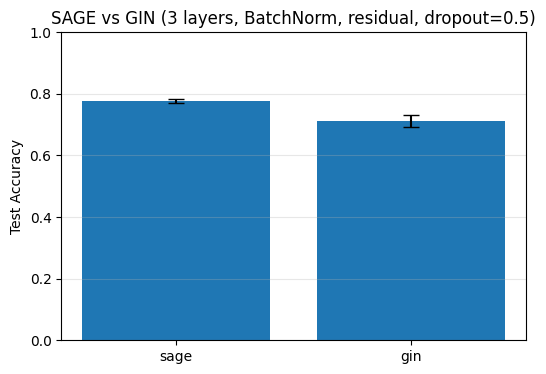

In [22]:
# Требуется: torch, torch_geometric, pandas, matplotlib, sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import copy
import pandas as pd
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import SAGEConv, GINConv, global_add_pool

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds = logits[mask].argmax(dim=1)
        acc = (preds == data.y[mask]).sum().item() / mask.sum().item()
    return acc


def make_norm(norm_type, dim):
    if norm_type is None:
        return None
    if norm_type == 'batch':
        return nn.BatchNorm1d(dim)
    if norm_type == 'layer':
        return nn.LayerNorm(dim)
    raise ValueError(f"Unknown norm: {norm_type}")


class SAGEModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=2, dropout=0.5,
                 norm_type=None, residual=False):
        super().__init__()
        assert num_layers >= 2, "num_layers >= 2"
        self.num_layers = num_layers
        self.dropout = dropout
        self.residual = residual

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        # первый слой
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        self.norms.append(make_norm(norm_type, hidden_dim))
        # скрытые слои (num_layers - 2)
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.norms.append(make_norm(norm_type, hidden_dim))
        # выходной слой
        self.convs.append(SAGEConv(hidden_dim, out_dim))
        # проекции для residual при необходимости
        self.res_projs = nn.ModuleList()
        for i in range(num_layers - 1):
            # если вход dim != hidden_dim, создаём проекцию при необходимости на forward
            self.res_projs.append(nn.Linear(hidden_dim, hidden_dim) if False else None)

    def forward(self, x, edge_index):
        # все слои кроме последнего
        for i in range(self.num_layers - 1):
            h_in = x
            x = self.convs[i](x, edge_index)
            if self.norms[i] is not None:
                x = self.norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            if self.residual:
                # если размерности отличаются, проецируем (для SAGE здесь размеры одинаковы)
                if h_in.shape[1] != x.shape[1]:
                    proj = nn.Linear(h_in.shape[1], x.shape[1]).to(x.device)
                    h_in = proj(h_in)
                x = x + h_in

        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

class GINModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=2, dropout=0.5,
                 norm_type=None, residual=False):
        super().__init__()
        assert num_layers >= 2, "num_layers >= 2"
        self.num_layers = num_layers
        self.dropout = dropout
        self.residual = residual

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        # GINConv требует MLP inside
        def make_mlp(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.ReLU(),
                nn.Linear(out_f, out_f)
            )

        # первый
        self.convs.append(GINConv(make_mlp(in_dim, hidden_dim)))
        self.norms.append(make_norm(norm_type, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GINConv(make_mlp(hidden_dim, hidden_dim)))
            self.norms.append(make_norm(norm_type, hidden_dim))
        # последний (выходной) — делаем MLP, но размер выходных логитов = out_dim
        self.convs.append(GINConv(make_mlp(hidden_dim, out_dim)))

    def forward(self, x, edge_index):
        for i in range(self.num_layers - 1):
            h_in = x
            x = self.convs[i](x, edge_index)
            if self.norms[i] is not None:
                x = self.norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            if self.residual:
                if h_in.shape[1] != x.shape[1]:
                    proj = nn.Linear(h_in.shape[1], x.shape[1]).to(x.device)
                    h_in = proj(h_in)
                x = x + h_in

        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


def train_and_eval(model, data, lr=0.005, weight_decay=5e-4, epochs=300, patience=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val = 0.0
    best_state = None
    epochs_no_improve = 0

    train_hist = []
    val_hist = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # eval
        model.eval()
        with torch.no_grad():
            train_acc = evaluate(model, data, data.train_mask)
            val_acc = evaluate(model, data, data.val_mask)

        train_hist.append(train_acc)
        val_hist.append(val_acc)

        if val_acc > best_val + 1e-12:
            best_val = val_acc
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc = evaluate(model, data, data.test_mask)
    return {
        'train_acc': train_hist[-1],
        'val_acc': best_val,
        'test_acc': test_acc,
        'train_hist': train_hist,
        'val_hist': val_hist
    }


def run_experiments(arch_list, seeds=[42,0,7], num_layers=3, hidden_dim=64,
                    norm_type=None, residual=False, dropout=0.5, epochs=300):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=NormalizeFeatures())
    data = dataset[0].to(device)

    records = []
    for arch in arch_list:
        results = {'train_acc': [], 'val_acc': [], 'test_acc': []}
        for seed in seeds:
            set_seed(seed)
            if arch == 'sage':
                model = SAGEModel(in_dim=dataset.num_node_features,
                                  hidden_dim=hidden_dim,
                                  out_dim=dataset.num_classes,
                                  num_layers=num_layers,
                                  dropout=dropout,
                                  norm_type=norm_type,
                                  residual=residual).to(device)
            elif arch == 'gin':
                model = GINModel(in_dim=dataset.num_node_features,
                                 hidden_dim=hidden_dim,
                                 out_dim=dataset.num_classes,
                                 num_layers=num_layers,
                                 dropout=dropout,
                                 norm_type=norm_type,
                                 residual=residual).to(device)
            else:
                raise ValueError(arch)

            res = train_and_eval(model, data, lr=0.005, weight_decay=5e-4, epochs=epochs, patience=60)
            print(f"[{arch} | seed={seed}] train={res['train_acc']:.4f} val={res['val_acc']:.4f} test={res['test_acc']:.4f}")
            results['train_acc'].append(res['train_acc'])
            results['val_acc'].append(res['val_acc'])
            results['test_acc'].append(res['test_acc'])

        records.append({
            'arch': arch,
            'num_layers': num_layers,
            'hidden_dim': hidden_dim,
            'norm_type': str(norm_type),
            'residual': residual,
            'train_mean': np.mean(results['train_acc']),
            'train_std': np.std(results['train_acc']),
            'val_mean': np.mean(results['val_acc']),
            'val_std': np.std(results['val_acc']),
            'test_mean': np.mean(results['test_acc']),
            'test_std': np.std(results['test_acc']),
        })
    df = pd.DataFrame(records)
    return df


if __name__ == "__main__":
    arch_list = ['sage', 'gin']   # две архитектуры: GraphSAGE и GIN
    seeds = [42, 0, 7]
    df_base = run_experiments(arch_list, seeds=seeds, num_layers=3, hidden_dim=64,
                              norm_type='batch', residual=True, dropout=0.5, epochs=300)

    print(df_base.to_string(index=False), '/n')

    # Визуализация: bar chart сравнение test_mean
    plt.figure(figsize=(6,4))
    plt.bar(df_base['arch'], df_base['test_mean'], yerr=df_base['test_std'], capsize=6)
    plt.ylabel('Test Accuracy')
    plt.title('SAGE vs GIN (3 layers, BatchNorm, residual, dropout=0.5)')
    plt.ylim(0,1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()


- sage показал лучший аккураси на валидации и тесте, чем gin
- при этом обе модели получили лучший результат при seed = 7

# Часть 2. Link Prediction

### 2.1 Реализация MLP-декодера

Вместо dot-product декодера:

$
s_{uv} = z_u^\top z_v
$

реализуйте:

$
s_{uv} = \mathrm{MLP}([z_u ,||, z_v])
$

Сравните качество (AUC, AP) с dot-product.

In [23]:
import torch
from torch_geometric.utils import train_test_split_edges

dataset = Planetoid(root='.', name='Cora')
data = dataset[0]
data = train_test_split_edges(data)   # автоматически создаются edge_train, edge_val, edge_test



In [24]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid_dim)
        self.conv2 = GCNConv(hid_dim, out_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        z = self.conv2(x, edge_index)
        return z

def decode_dot(z, edge_index):
    src, dst = edge_index
    score = (z[src] * z[dst]).sum(dim=1)   # dot product
    return torch.sigmoid(score)

class MLPDecoder(torch.nn.Module):
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(2*dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, 1)
        )

    def forward(self, z, edge_index):
        src, dst = edge_index
        h = torch.cat([z[src], z[dst]], dim=1)   # [z_u || z_v]
        score = self.mlp(h).squeeze()
        return torch.sigmoid(score)



In [25]:
from torch_geometric.utils import negative_sampling

def get_positive_negative_edges(data, split):
    pos = data[f'{split}_pos_edge_index']
    neg = negative_sampling(
        edge_index=data.train_pos_edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos.size(1)
    )
    return pos, neg


In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score

def compute_metrics(model, decoder, data, split):
    model.eval()
    with torch.no_grad():
        z = model(data.x, data.train_pos_edge_index)

        pos_edges = data[f'{split}_pos_edge_index']
        neg_edges = data[f'{split}_neg_edge_index']

        pos_pred = decoder(z, pos_edges)
        neg_pred = decoder(z, neg_edges)

        y_true = torch.cat([torch.ones_like(pos_pred), torch.zeros_like(neg_pred)])
        y_score = torch.cat([pos_pred, neg_pred])

        auc = roc_auc_score(y_true.cpu(), y_score.cpu())
        ap  = average_precision_score(y_true.cpu(), y_score.cpu())

    return auc, ap


In [27]:
def train_linkpred(encoder, decoder, data, epochs=300, lr=0.01):
    encoder.train()
    decoder.train()

    opt = torch.optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=lr
    )

    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        opt.zero_grad()

        z = encoder(data.x, data.train_pos_edge_index)

        pos_edges = data.train_pos_edge_index
        neg_edges = negative_sampling(
            pos_edges, data.num_nodes, pos_edges.size(1)
        )

        pos_pred = decoder(z, pos_edges)
        neg_pred = decoder(z, neg_edges)

        labels = torch.cat([torch.ones_like(pos_pred), torch.zeros_like(neg_pred)])
        preds  = torch.cat([pos_pred, neg_pred])

        loss = F.binary_cross_entropy(preds, labels.float())
        loss.backward()
        opt.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss={loss.item():.4f}")


In [28]:
class DotProductDecoder(torch.nn.Module):
    def forward(self, z, edge_index):
        src, dst = edge_index
        score = (z[src] * z[dst]).sum(dim=1)
        return torch.sigmoid(score)


In [30]:

hid = 64
out = 64

encoder_dot = DotProductDecoder()
train_linkpred(encoder_dot, decoder_dot, data)


auc_dot, ap_dot = compute_metrics(encoder_dot, decode_dot, data, "test")
print("\n Dot product ")
print("AUC:", auc_dot)
print("AP :", ap_dot)


encoder_mlp = GCNEncoder(data.x.size(1), hid, out)
decoder_mlp = MLPDecoder(dim=out)

train_linkpred(encoder_mlp, decoder_mlp, data)

auc_mlp, ap_mlp = compute_metrics(encoder_mlp, decoder_mlp, data, "test")
print("\nMLP decoder")
print("AUC:", auc_mlp)
print("AP :", ap_mlp)


ValueError: optimizer got an empty parameter list

### 2.2 Эксперимент с negative sampling ratio

Попробуйте соотношения:

```
1:1, 1:2, 1:5, 1:10
```

Постройте таблицу для AUC и AP. Опишите полученные результаты


In [31]:
def train_linkpred_negratio(encoder, decoder, data, neg_ratio=1, epochs=300, lr=0.01):
    encoder.train()
    decoder.train()
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        z = encoder(data.x, data.train_pos_edge_index)

        pos_edges = data.train_pos_edge_index
        num_neg = pos_edges.size(1) * neg_ratio

        neg_edges = negative_sampling(
            edge_index=pos_edges,
            num_nodes=data.num_nodes,
            num_neg_samples=num_neg
        )

        pos_pred = decoder(z, pos_edges)
        neg_pred = decoder(z, neg_edges)

        labels = torch.cat([torch.ones_like(pos_pred), torch.zeros_like(neg_pred)])
        preds  = torch.cat([pos_pred, neg_pred])

        loss = F.binary_cross_entropy(preds, labels.float())
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")


In [32]:
neg_ratios = [1, 2, 5, 10]

results = []

# Используем MLP-decoder для примера
encoder = GCNEncoder(data.x.size(1), 64, 64)
decoder = MLPDecoder(64)

for ratio in neg_ratios:
    print(f"\n Negative ratio {ratio}:1")
    train_linkpred_negratio(encoder, decoder, data, neg_ratio=ratio)
    auc, ap = compute_metrics(encoder, decoder, data, split="test")
    results.append((ratio, auc, ap))


print("\nNegative Sampling Ratio Results")
print("Ratio | AUC   | AP")
for ratio, auc, ap in results:
    print(f"{ratio}:1  | {auc:.4f} | {ap:.4f}")



 Negative ratio 1:1
Epoch 000 | Loss: 0.6932
Epoch 050 | Loss: 0.2704
Epoch 100 | Loss: 0.1302
Epoch 150 | Loss: 0.1173
Epoch 200 | Loss: 0.1083
Epoch 250 | Loss: 0.0630

 Negative ratio 2:1
Epoch 000 | Loss: 0.0721
Epoch 050 | Loss: 0.0840
Epoch 100 | Loss: 0.0624
Epoch 150 | Loss: 0.0505
Epoch 200 | Loss: 0.0431
Epoch 250 | Loss: 0.0420

 Negative ratio 5:1
Epoch 000 | Loss: 0.0465
Epoch 050 | Loss: 0.0450
Epoch 100 | Loss: 0.0372
Epoch 150 | Loss: 0.0374
Epoch 200 | Loss: 0.0282
Epoch 250 | Loss: 0.0282

 Negative ratio 10:1
Epoch 000 | Loss: 0.0233
Epoch 050 | Loss: 0.0279
Epoch 100 | Loss: 0.0219
Epoch 150 | Loss: 0.0198
Epoch 200 | Loss: 0.0169
Epoch 250 | Loss: 0.0164

Negative Sampling Ratio Results
Ratio | AUC   | AP
1:1  | 0.8622 | 0.8913
2:1  | 0.8523 | 0.8862
5:1  | 0.8473 | 0.8866
10:1  | 0.8441 | 0.8887


Опишите полученные результаты
- лучшие показания метрик достигаются при ratio = 1:1
- дальнейшие изменения ratio приводят к падению метрик


### 2.3 Оптизация текущей модели
Попробуйте улучшить текущую модель за счет использования следующих модификаций:
- добавление нормализации (BatchNorm / LayerNorm / PairNorm)
- Dropout
- residual connection

Опишите полученные результаты


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, PairNorm

class ResidualGCNLayerLP(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5, use_bn=True):
        super().__init__()
        self.gcn = GCNConv(in_dim, out_dim)
        self.dropout = dropout
        self.use_bn = use_bn
        self.bn = nn.BatchNorm1d(out_dim) if use_bn else None

        if in_dim != out_dim:
            self.res_proj = nn.Linear(in_dim, out_dim)
        else:
            self.res_proj = None

    def forward(self, x, edge_index):
        residual = x
        out = self.gcn(x, edge_index)
        out = F.relu(out)
        if self.bn is not None:
            out = self.bn(out)
        out = F.dropout(out, p=self.dropout, training=self.training)

        if self.res_proj is not None:
            residual = self.res_proj(residual)

        return out + residual


In [34]:
class ResidualGCNEncoderLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.layer1 = ResidualGCNLayerLP(in_dim, hidden_dim, dropout=dropout)
        self.layer2 = ResidualGCNLayerLP(hidden_dim, out_dim, dropout=dropout, use_bn=False)

    def forward(self, x, edge_index):
        x = self.layer1(x, edge_index)
        x = self.layer2(x, edge_index)
        return x


In [35]:
class MLPDecoderLP(nn.Module):
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2*dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, z, edge_index):
        src, dst = edge_index
        h = torch.cat([z[src], z[dst]], dim=1)
        return torch.sigmoid(self.mlp(h).squeeze())


In [36]:
def train_linkpred_improved(encoder, decoder, data, neg_ratio=1, epochs=300, lr=0.01):
    encoder.train()
    decoder.train()
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        z = encoder(data.x, data.train_pos_edge_index)

        pos_edges = data.train_pos_edge_index
        num_neg = pos_edges.size(1) * neg_ratio
        neg_edges = negative_sampling(pos_edges, num_nodes=data.num_nodes, num_neg_samples=num_neg)

        pos_pred = decoder(z, pos_edges)
        neg_pred = decoder(z, neg_edges)

        labels = torch.cat([torch.ones_like(pos_pred), torch.zeros_like(neg_pred)])
        preds  = torch.cat([pos_pred, neg_pred])

        loss = F.binary_cross_entropy(preds, labels.float())
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss={loss.item():.4f}")


In [37]:
encoder = ResidualGCNEncoderLP(data.x.size(1), hidden_dim=64, out_dim=64, dropout=0.5)
decoder = MLPDecoderLP(64)

train_linkpred_improved(encoder, decoder, data, neg_ratio=1)

# Оценка
auc, ap = compute_metrics(encoder, decoder, data, split="test")
print(f"\nImproved LP Model | AUC={auc:.4f} | AP={ap:.4f}")


Epoch 000 | Loss=0.7079
Epoch 050 | Loss=0.1124
Epoch 100 | Loss=0.0755
Epoch 150 | Loss=0.0557
Epoch 200 | Loss=0.0469
Epoch 250 | Loss=0.0496

Improved LP Model | AUC=0.9094 | AP=0.9278


Опишите результаты:
- оптимизация прошла успешно - качество значительно выросло с 86% до 90%

### 2.4 Реализация и сравнение GCN / GraphSAGE / GAT / GIN
Выберите 2 базовые архитектуры из списка: GraphSAGE, GAT(v2), GIN. Реализуйте их для задачи node classification и сравните полученные результаты.

Комментарий: при реализации, можно использовать наработки с предыдущих пунктов - добавлять разные виды модификаций (увеличивать число слоев / добавлять слои нормализации / residual conections...)


In [41]:
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


In [38]:
class GATv2(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gat2(x, edge_index)
        return F.log_softmax(x, dim=1)


In [39]:
def train(model, data, lr=0.005, weight_decay=5e-4, epochs=300):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        opt.step()

    return evaluate(model, data, data.test_mask)


def evaluate(model, data, mask):
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum()
    return (int(correct) / int(mask.sum()))


In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    SAGEConv,
    GATv2Conv,
)


In [44]:
dataset = Planetoid(root="/tmp/Cora", name="Cora", transform=NormalizeFeatures())
data = dataset[0]

sage_model = GraphSAGE(in_dim=1433, hidden_dim=64, out_dim=7)
gat_model  = GATv2(in_dim=1433, hidden_dim=32, out_dim=7, heads=4)

sage_test_acc = train(sage_model, data)
gat_test_acc  = train(gat_model, data)


In [45]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["GraphSAGE", "GATv2"],
    "Test Accuracy": [sage_test_acc, gat_test_acc]
})

print(df)


       Model  Test Accuracy
0  GraphSAGE          0.796
1      GATv2          0.709


Опишите результаты:
- лучшее акураси получилось у GraphSAGE, причем значительно лучше
- но! сильно хуже чем в предыдущей модели( improved MLP)!
